In [29]:
# %% SECTION 1: Packages import
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Import other packages as necessary


In [30]:
# %% SECTION 2: Helper functions
# Define functions if needed


In [43]:
def gate_model(tau, x_0,x_inf,dt):
    y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))
    return y

#probably needs to be fixed, we need to make the gates opening dependent on voltage as well somehow
def get_current(e_r, g_bar, tau_m, tau_h, m_inf, h_inf, v, t, v_steps): 
    m = np.zeros(len(v))
    h = np.zeros(len(v))


    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        m_inf_step = np.interp(v[i], v_steps, m_inf)
        h_inf_step = np.interp(v[i], v_steps, h_inf)

        m[i] = gate_model(tau_m, m[i-1], m_inf_step, dt)
        h[i] = gate_model(tau_h, h[i-1], h_inf_step, dt)

    return g_bar * (v - e_r) * m * h

def compute_error(params, t, v, test_i, v_steps):
    e_r, g_bar, tau_m, tau_h = params[:4]
    m_inf = params[4:4+len(v_steps)]
    h_inf = params[4+len(v_steps):4+2*len(v_steps)]
    return get_current(e_r, g_bar, tau_m, tau_h, m_inf, h_inf, v, t, v_steps) - test_i

Fitted parameters: [-4.81042458e+01  9.89917984e+00  2.33080083e-03  7.26217802e+00
  2.31341961e-04  3.80710775e-04 -3.29816841e-04  1.25953919e-05
  8.66112373e-05  5.93514553e-05  3.50379420e-01  5.70696755e-01
  9.04664596e-01  1.47041150e-01  3.03813525e-01 -1.01524838e-01]
Fit succeeded: True


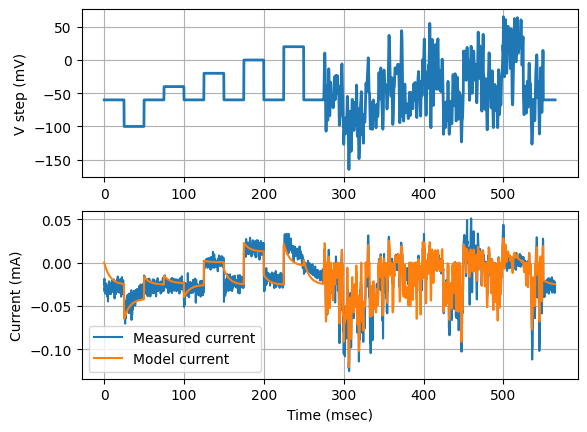

In [44]:
# %% SECTION 3: Main function
def run_vclamp_model(folder: str, data: str = "data/CookLab1UnknownChannelExtra.txt"):
    """
    Compute current from voltage-clamp input.

    Parameters
    ----------
    folder :
        Directory with input file for voltage-clamp model.
    data :
        Name of input file.
    # Please list any parameters added to the function.

    Returns
    -------
    np.ndarray
        Output current computed by the voltage-clamp model.
    """
    # %% SECTION 3-a: Load provided input data.
    # NO MODIFICATIONS: This section should be kept as is.
    data = np.loadtxt(os.path.join(folder, data))
    t = data[:, 0]
    v = data[:, 1]
    test_i = data[:,2]
    v_steps = [-100, -60, -40, -20, 0, 20]

    # i has the same shape as array v, add code in the next section to fill it
    i = np.empty_like(v)

    # %% SECTION 3-b: Compute i [to be filled by students]
    initial_m_inf = [0.01, 0.05, 0.2, 0.5, 0.8, 0.95]
    initial_h_inf = [0.99, 0.95, 0.8, 0.5, 0.2, 0.05]
    fit = least_squares(compute_error, args = (t, v, test_i, v_steps), x0 = [-60, 10, 1, 1, *initial_m_inf, *initial_h_inf])

    print("Fitted parameters:", fit.x)
    print("Fit succeeded:", fit.success)    
    
    i = get_current(fit.x[0], fit.x[1],fit.x[2], fit.x[3], fit.x[4:4+len(v_steps)], fit.x[4+len(v_steps):4+2*len(v_steps)], v, t, v_steps)
    
    plt.figure()

    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(t, v, linewidth=2)
    plt.axis("tight")
    plt.ylabel("V step (mV)")

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(t, test_i, label="Measured current")
    plt.plot(t, i, label="Model current")
    plt.xlabel("Time (msec)")
    plt.ylabel("Current (mA)")
    plt.legend()

    # %% SECTION 3-c: Assert validity of output and return it.
    # NO MODIFICATIONS: This section should be kept as is.
    assert len(i.shape) == 1, "Currrent array should be 1-dimensional"
    return i

fitted = run_vclamp_model(os.getcwd())


Fitted parameters: [-1.27724192e+01  5.68676061e-04  1.49473058e-01  1.21953203e+04]
Fit succeeded: True


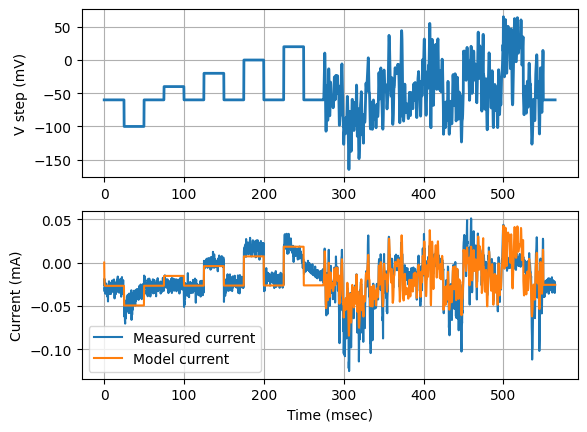

In [ ]:
# %% SECTION 4: Function calls
if __name__ == "__main__":
    # Replace this with the path to the folder where provided input .txt file is!
    folder = ""

    # Run function on the voltage-clamp data
    i = run_vclamp_model(folder)